
# How to check all possible binding sites of a target sequence i.e. a list of queries against binding interactions with transcripts (references) of a transcriptome (reference library)
We have a target mRNA that we want to bind with RNA binding proteins or guide RNAs. To design these binding sequences we need to select binding sites on our target mRNA which are very unique, i.e. ideally dont occure elsewhere the transcriptome.  Or more general: We have a target sequence and we want to find a subsequence of specified length which is as specific to this target as possible i.e. has the least interactions with list of reference sequences. 

**This notebook is focused on testing and building up step by step the basic algorithm using random sequences.** To see the algorithm applied to real sequences see the "main" notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numba import njit
from joblib import Parallel, delayed
from tqdm import tqdm
import pathlib
import math
import warnings
from IPython.display import display
#import mplcyberpunk
#plt.style.use("cyberpunk")
from pprint import pprint as _pprint
def pprint(*args):
    _pprint(*args, sort_dicts=False)

@njit  # just in time compilation speeds up sequence comparison, also see seq_compare_runtime file
def sc_jit2(seq:bytes|str, ref:bytes|str):
    '''A fast Sequence Comparison of a short query sequence (seq) against a larger reference (ref).
    Returns the number of mismatches for every position the sort sequence could bind to the larger one. Consideres only full overlap binding, i.e. no overhangs '''

    n = len(ref) - len(seq) + 1
    if n<1: print("sc_jit: wrong argument order")
    cv = np.zeros(n, dtype=np.uint16) 
    for i in range(n):
        matches = 0
        for j in range(len(seq)):
            if ref[i + j] == seq[j]:
                matches += 1
        cv[i] = len(seq)-matches
    return cv

def random_seq(size:int):
    '''returns a random ACGT sequence of length = size'''
    return ''.join(np.array(["A", "C", "G", "T"])[np.random.randint(low = 0, high = 4, size = size)])

sc_jit2(random_seq(10), random_seq(10));    # call it once so that numba compiles it

print("2with string encoding \t ", end = "")
%timeit sc_jit2(random_seq(10).encode(), random_seq(100).encode())
print("2without string encode \t ", end = "")
%timeit sc_jit2(random_seq(10), random_seq(100))

2with string encoding 	 49.1 μs ± 362 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
2without string encode 	 54.4 μs ± 6.43 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


# QxR: Search for binding-sites on single transcript 
= global sequence comparison of query with a reference sequence
- as we are searching for binding sites in the transcriptome, we'd ideally find as few as possible to avoid unwanted side-effects.
- as the binding sites are already short the probability of binding with loops is very low -> a global sequence alignment search should suffice (we dont need BLAST)

In [2]:
query       = pd.Series({"SEQ_NAME": "rand_candidate",  "SEQUENCE": random_seq(size = 4)})       # the query sequence i.e. a candidate binding sequence for the target 
reference   = pd.Series({"SEQ_NAME": "rand_transcript", "SEQUENCE": random_seq(size = 280)})     # The reference to check against, i.e. a transcript from the transcriptome in this example

display(pd.DataFrame([query, reference]) )

,SEQ_NAME,SEQUENCE
0,rand_candidate,ATGC
1,rand_transcript,CAGGGTCAACAGTGATGGTGATTTGGCCTATGGGTCGCCTAGTACC...


In [3]:
def scan_QxR(query:pd.Series,reference:pd.Series, skip_summary = False, mm_energy  = 2.5, plot = False, max_k = None):
    '''
    scans a reference for possible binding sites of query: Q|R 
    mm_energy = (positive signed) energy of complementary nucleotides in kT

    returns     ...
    '''
    
    
    
    output = {}
    
    # I dunno why but its faster in bytes, but it is so lets always convert it
    if type(query.SEQUENCE) == str:
        seq = query.SEQUENCE.encode()
        ref = reference.SEQUENCE.encode()
    elif type(query.SEQUENCE) == bytes:
        seq = query.SEQUENCE
        ref = reference.SEQUENCE
    
    # check every posible position of query to bind at ref and count numebr of mismatched nucleotides
    mismatch_profile = sc_jit2(seq, ref) # outsourced into its own pre compiled function to speed up runtime
    
    if not skip_summary or plot:     # summarize interaction
        if max_k == None:
            max_k = mismatch_profile.min()+3
        QR_summary = {"boltzmann factor" : np.sum(np.exp(-mm_energy*mismatch_profile.astype(float)))}|{f"{k} mismatch": (mismatch_profile==k).sum() for k in range(0, max_k+1)}

    # assemble output
    output["mismatch_profile"] = mismatch_profile
    if not skip_summary:          
        output["QR_summary"]       = QR_summary

    #//////////////////////////////////////////////////////////////////////////////////////////////////////#
    
    if plot != False:
        import matplotlib.pyplot as plt
        from matplotlib.ticker import MaxNLocator
        plt.figure(figsize = (18,3))
        plt.bar(range(len(mismatch_profile)), len(seq)-mismatch_profile, width = 1, alpha = 0.5)
        for k in range(mismatch_profile.min(), mismatch_profile.min()+2):
            plt.plot(np.flatnonzero(mismatch_profile==k), [len(seq)-k]*(mismatch_profile==k).sum(), 'x')
        ax = plt.gca()
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.ylabel("# mismatches");
        plt.xlabel("position on reference");
        plt.yticks([tick for tick in plt.yticks()[0] if tick <= len(seq)],[int(len(seq)-tick) for tick in plt.yticks()[0] if tick <= len(seq)]);
        ax.set_ylim(-.5, len(seq)+.5)
        ax.set_xlim(-.01*len(mismatch_profile), 1.01* len(mismatch_profile))


        if plot == "show" or plot == True:
            plt.show()
        elif plot == "return":
            from io import BytesIO             # Save the figure to a BytesIO object
            buf = BytesIO()
            plt.savefig(buf, format='webp')
            output['plot'] = buf.getvalue()  # This is the image data stored in a variable
        else:
            plt.savefig(plot)

    return output

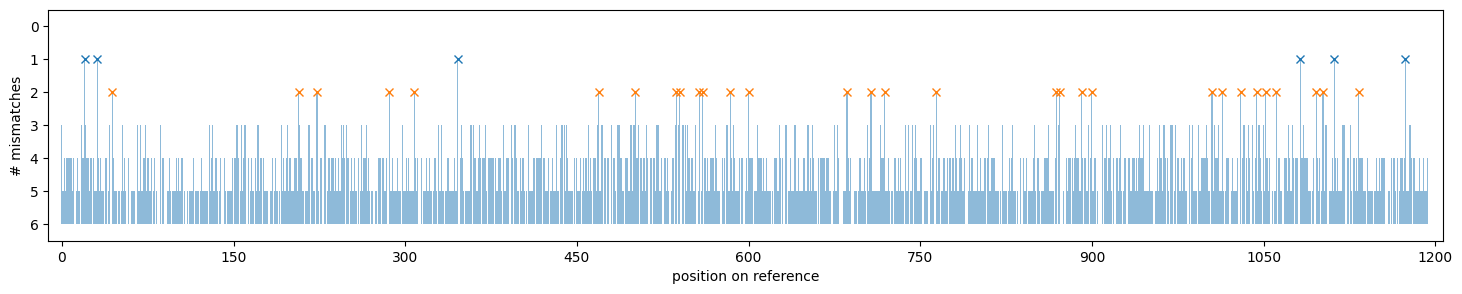

{'boltzmann factor': np.float64(0.7852631938537485),
 '0 mismatch': np.int64(0),
 '1 mismatch': np.int64(6),
 '2 mismatch': np.int64(30),
 '3 mismatch': np.int64(131),
 '4 mismatch': np.int64(362)}


In [4]:
query = pd.Series({"SEQ_NAME": "rand_candidate",  "SEQUENCE": random_seq(size = 6)})        # the query sequence i.e. a candidate binding sequence for the target 
ref   = pd.Series({"SEQ_NAME": "rand_transcript", "SEQUENCE": random_seq(size = 1200)})     # The reference to check against, i.e. a transcript from the transcriptome in this example
pprint(scan_QxR(query, ref, plot=True)["QR_summary"])

In [5]:
%%timeit
query = pd.Series({"SEQ_NAME": "rand_candidate",  "SEQUENCE": random_seq(size = 6)})        # the query sequence i.e. a candidate binding sequence for the target 
ref   = pd.Series({"SEQ_NAME": "rand_transcript", "SEQUENCE": random_seq(size = 1200)})     # The reference to check against, i.e. a transcript from the transcriptome in this example
scan_QxR(query, ref, plot=False)

318 μs ± 4.45 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


# Search for binding-sites in a transcriptome
= compare a query to a list of reference sequences

In [21]:
def round_format(x, digits = 3):
    '''round numbers to "digits" significant digits. i.e. 1234 with digits = 2 -> 1200, and 0.1234 -> 0.12'''
    if x == 0: return 0
    mag = -int(np.floor(np.log10(x))-digits+1)
    return np.round(x, mag).astype([int, float][int(mag > 0)])



def _summarize_xRL(QxRL_results, QxT_results=None, metrics = ['boltzmann factor'], relative_to_target=False, use_weights=False, VIR_max=8, plot = False):
    xRL_summary = query.to_dict()
    if plot:
        fig, axes = plt.subplots(len(metrics), 1, figsize = (12, (3 + .5*int(use_weights))*len(metrics)))

    for i, metric in enumerate(metrics): # iterate over all the metrics that should be summarized
    
        ref_metric = QxRL_results[metric]         # results of comparing the query i.e. candidate sequence against the Reference list. metrics from references -> ref_metric
        if relative_to_target: trg_metric = QxT_results[metric]             # results of comparing the query i.e. candidate sequence against the Target sequence.   metrics from target   -> trg_metric
        if use_weights:   # weighted metric -> wetric
            ref_wetric = QxRL_results[metric] * QxRL_results["WEIGHT"]
            if relative_to_target: trg_wetric = QxT_results[metric] * QxT_results["WEIGHT"]
    
        if "oltzman" in metric and relative_to_target:               # for the Boltzmann factor it is compared to the Boltzmann factor of the query sequence --> relative comparison of query binding to the target vs transcripts
            insert = " r2t"; norm = trg_metric        # = "relative to target". used for column name
            if use_weights: norw = trg_wetric         # norw = normalization for weighted data
        else:  insert = "";   norm = 1;   norw = 1    # the mismatch count data is not re-normalized
    
        # summarize the sequence comparison results: sum = total number of binding sites, while max = maximum number of binding sites per reference sequence i.e. transcript
        xRL_summary[ metric + f" max" + insert] = ref_metric.max() / norm        # What was the highest number of off-target binding sites on a single reference i.e. transcript
        xRL_summary[ metric + f" sum" + insert] = ref_metric.sum() / norm        # What was the  total  number of off-target binding sites on the whole reference list i.e. transcriptome
        if use_weights:
            xRL_summary[ metric + f" W.max" + insert] = ref_wetric.max() / norw        # What was the highest number of off-target binding sites on a single reference i.e. transcript
            xRL_summary[ metric + f" W.sum" + insert] = ref_wetric.sum() / norw        # What was the  total  number of off-target binding sites on the whole reference list i.e. transcriptome
            if ('oltzman' in metric or plot) and VIR_max > 0:
                VIR_selec = ((ref_wetric > sorted(ref_wetric)[-min(VIR_max, len(ref_wetric))]) | (ref_wetric == ref_wetric.max()) * (ref_wetric != ref_wetric.min())) ## (ref_metric > sorted(ref_metric)[-10]) returns the 10th largest value, also ever value equal to the largest one is included. Overrulling everything else is the exclusion of the min value
                VIR_names = QxRL_results.iloc[ref_wetric[VIR_selec].sort_values(ascending = False).index].SEQ_NAME  # Store Very Important References i.e. those with strong offtarget binding sites
                if 'oltzman' in metric: xRL_summary[ metric + " W.VIR" + insert] = VIR_names.tolist()
        elif ('oltzman' in metric or plot) and VIR_max > 0:
            VIR_selec = ((ref_metric > sorted(ref_metric)[-min(VIR_max, len(ref_metric))]) | (ref_metric == ref_metric.max()) * (ref_metric != ref_metric.min())) ## (ref_metric > sorted(ref_metric)[-10]) returns the 10th largest value, also ever value equal to the largest one is included. Overrulling everything else is the exclusion of the min value
            VIR_names = QxRL_results.iloc[ref_metric[VIR_selec].sort_values(ascending = False).index].SEQ_NAME  # Store Very Important References i.e. those with strong offtarget binding sites
            if 'oltzman' in metric: xRL_summary[ metric + " VIR" + insert] = VIR_names.tolist()
            
        
        #------------------------------------------------------#
        #                 Plotting the results                 #   
        #------------------------------------------------------#
        
        # still within the same for loop iterating over every metric 
        # Note: I know this is not very clean code, but I dont want to touch it again myself as it would probably fall apart
        if plot:
    
            ax = axes[i]
            
            xmax = len(ref_metric) # number of references
            sy = 1  # weighted data is shown in the same plot, but needs a seperate, rescaled y-axis. sy is this rescaling factor
            if use_weights: 
                if relative_to_target: _data = pd.concat([QxRL_results, pd.DataFrame([QxT_results ])], axis = 0)
                else:   _data = QxRL_results
                if _data[metric].max() != 0 and (_data[metric]*_data.WEIGHT).max() != 0 and (_data[metric]*_data.WEIGHT).min() >= 0: # avoid divide by zero in case of no data 
                    sy = _data[metric].max() / (_data[metric]*_data.WEIGHT).max() # internal rescaling factor for the split y axis
                if relative_to_target:
                    sy /= norm/norw
            
            ax.plot(        [0, xmax],                [0, 0], zorder = 10, color = "black", lw = 1) # plot black zero line for references
            if relative_to_target: ax.plot([-.032*xmax, -.028*xmax], [0, 0], zorder = 10, color = "black", lw = 1) # plot black zero line for target
            ax.fill_between(        np.arange(xmax),           ref_metric/norm,              ref_metric*0, color = "tab:blue", ec = "tab:blue", lw = .5, label = "unweighted")    # plot unweighted results of references
            if relative_to_target: ax.fill_between([-.032*xmax, -.028*xmax], [trg_metric/norm, trg_metric/norm], [0,0],   color = "tab:blue", ec = "tab:blue", lw = .5)                          # plot unweighted results of target
    
            if use_weights:
                ax.fill_between(        np.arange(xmax),           -ref_wetric*sy/norw,                   ref_wetric*0,  color = "tab:orange", ec = "tab:orange", lw = .5, label = "weighted")           # plot weighted results of references
                if relative_to_target: ax.fill_between([-.032*xmax, -.028*xmax], [-trg_wetric*sy/norw, -trg_wetric*sy/norw], [0,0],     color = "tab:orange", ec = "tab:orange", lw = .5)                               # plot weighted results of target
                ax.legend(loc = "upper right")
    
            message = "" # for figure titles
            if "match" in metric: # for the (mis) match count data
                ax.set_ylabel("number of binding sites")
                if ref_metric.max() > 0:  # i.e. if there are mismatches to plot.
                    message = f"  »  max {ref_metric.max()}x on {(ref_metric == ref_metric.max()).sum()} reference{'s'*int((ref_metric == ref_metric.max()).sum() != 1)}"
            elif "oltzma" in metric: # for the boltzmann factors
                if use_weights:  message =  f" »  w.sum≈{round_format(ref_wetric.sum()/norw)} " + insert
                else:            message =  f" »  sum≈{  round_format(ref_metric.sum()/norm)} " + insert
                if relative_to_target: ax.set_ylabel("relative binding frequency")
                else:   ax.set_ylabel("binding frequency [au]")
    
            ax.set_title(metric + message)
    
            # x-axis formatting
            ax.set_xlabel("reference sequence name")
            
            if relative_to_target: 
                ax.set_xticks(np.concatenate([[-0.03*xmax], VIR_names.index]), labels = np.concatenate([["target"], VIR_names.tolist()]), fontsize = 8, rotation = 45,  ha='right')   
                ax.set_xlim(-0.05*xmax, 1.01*xmax)
    
            else:  
                ax.set_xticks(VIR_names.index, labels =  VIR_names.tolist(), fontsize = 8, rotation = 45,  ha='right')
                ax.set_xlim(-0.01*xmax, 1.01*xmax)
        
            # split y axis formatting
            yt = ax.get_yticks().copy()
            ax.set_yticks(yt[yt>=0])
            sec_y = ax.secondary_yaxis("left", functions = (lambda y: -y/sy, lambda y: -y*sy))
            plt.tight_layout() # need to be called before getting ytick values as this triggers matplotlib to calculate the layout and the ticks correctly.
            yt2 = sec_y.get_yticks()
            sec_y.set_yticks(yt2[yt2>0])

    if plot:
        plt.tight_layout(h_pad=4, rect = [0.1, 0.1, 0.9, 0.9])
        if plot == "show" or plot == True:
            plt.show()
        else:
            plt.savefig(plot)
            plt.close()
    
    return xRL_summary

In [22]:
def scan_QxRL(query, reference_list, target = None, relative_to_target = False, use_weights = False , VIR_max = 8, skip_summary = False, plot = False, mm_energy=2.5):
    
    '''searches for (partial) matches between query sequence and reference list
    query: sequence to be found (pd.Series object)
    reference_list: pd.DataFrame of sequences to test against
    Both need at least a SEQ_NAME and a SEQUENCE column
    Returns copy of reference_list with new columns containing the results
    relative_to_target: the query gets evaluated not only against the reference list, but the target as well. In the summary the boltzmann factors i.e. binding affinities against the references will be relative to the affinity to the wholetarget sequence 
    '''
    output = {}
    
    #-------------------------------------------------#
    #              input arguments check              #  -> checks if the parameters have expected datatype to prevent errors later on
    #-------------------------------------------------#
    
    # check arguments data types
    if not type(reference_list) == pd.DataFrame: raise TypeError("unsupported type for 'reference_list', use pandas.DataFrame")
    if not ("SEQ_NAME" in reference_list.columns and "SEQUENCE" in reference_list.columns):
        raise TypeError('reference_list does not contain required columns: SEQ_NAME, SEQUENCE')
    if type(query) == pd.Series:  pass # everything is fine
    elif type(query) == str:           # convert to pandas series
        warnings.warn("Warning, deprecated input type for query: string. Please use pandas.Series!")
        query = pd.Series({"SEQ_NAME": "unnamed", "SEQUENCE": query})
    elif type(query) == pd.DataFrame and len(query) == 1:
        warnings.warn("Warning, query had to be converted from pandas.DataFrame to pandas.Series!")
        query = query.iloc[0]
    else: raise TypeError("unsupported type for 'query', use pandas.Series")
    
    if relative_to_target:
        if not type(target) == pd.Series: raise TypeError("unsupported type for 'target', use pandas.Series")
        if not ("SEQ_NAME" in target.keys() and "SEQUENCE" in target.keys()):
            raise TypeError('target does not contain required keys: SEQ_NAME, SEQUENCE')
        
    if use_weights:  # check if the input data is okay to use weighted evalutation
        if "WEIGHT" in reference_list.columns:
            invalid = reference_list.WEIGHT.isin([np.inf, -np.inf, np.nan])
            if invalid.any():  raise ValueError(f"{invalid.sum()} entries with nan or inf WEIGHT in reference_list.")
        else:   raise TypeError("reference_list: No WEIGHT column found, to switch to unweighted mode set use_weights = False")
        if relative_to_target:
            if "WEIGHT" in target.keys():
                valid = math.isfinite(target.WEIGHT)
                if not valid:  raise ValueError(f"target has nan or inf WEIGHT.")
            else:   raise TypeError("target: No WEIGHT key found, to switch to unweighted mode set use_weights = False")
            
        
    # check how many different nucleotides occure in the provided sequences
    nts = set(reference_list.SEQUENCE.sample(20).sum()) | set(reference_list.SEQUENCE.iloc[:10].sum()) | set(reference_list.SEQUENCE.iloc[-10:].sum()) | set(query.SEQUENCE)
    if len(nts) != 4: 
        raise ValueError(f"Warning, expected 4 types of nucleoties in the input, found (at least) {len(nts)}")
    
    #---------------------------------------------------------------#
    #  Search for binding sites in reference list and on target  #
    #---------------------------------------------------------------# 
    batch_QxR_results = [scan_QxR(query, ref, skip_summary=False, mm_energy=mm_energy)['QR_summary'] for i, ref in reference_list.iterrows()] # iterate over all reference sequences; and the target itself as control 
    QxRL_results = pd.concat([reference_list, pd.DataFrame(batch_QxR_results, reference_list.index)], axis = 1)   # convert to pandas dataframe and add original columns 
    output['QxRL_results'] = QxRL_results
    if relative_to_target:
        max_k = max([int(col[:-8]) for col in QxRL_results.columns if col[-8:] == 'mismatch'])
        QxT_results = pd.concat([target, pd.Series(scan_QxR(query, target, skip_summary=False, max_k=max_k)['QR_summary'])])
        output['QxT_results'] = QxT_results
    else: QxT_results = None
    
    metrics = []
    for _m in list(QxRL_results.columns):
        if not _m in metrics and not _m in list(reference_list.columns): metrics.append(_m)
      
    to_drop = [c for c in metrics if QxRL_results[c].isna().any()]
    QxRL_results = QxRL_results.drop(columns=to_drop)
    if relative_to_target: QxT_results = QxT_results.drop(columns=to_drop)
    metrics = [m for m in metrics if not m in to_drop]
    
    
    #-------------------------------------------------------------#
    #                   Summarize QxRL results                    #
    #-------------------------------------------------------------# 
    
    if not skip_summary or plot:
        xRL_summary = _summarize_xRL(QxRL_results, QxT_results, metrics, relative_to_target, use_weights, VIR_max, plot)
        output['QxRL_summary'] = xRL_summary
    
    return output


/tmp/ipykernel_62370/2921249183.py:106: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(h_pad=4, rect = [0.3, 0.3, 0.7, 0.7])


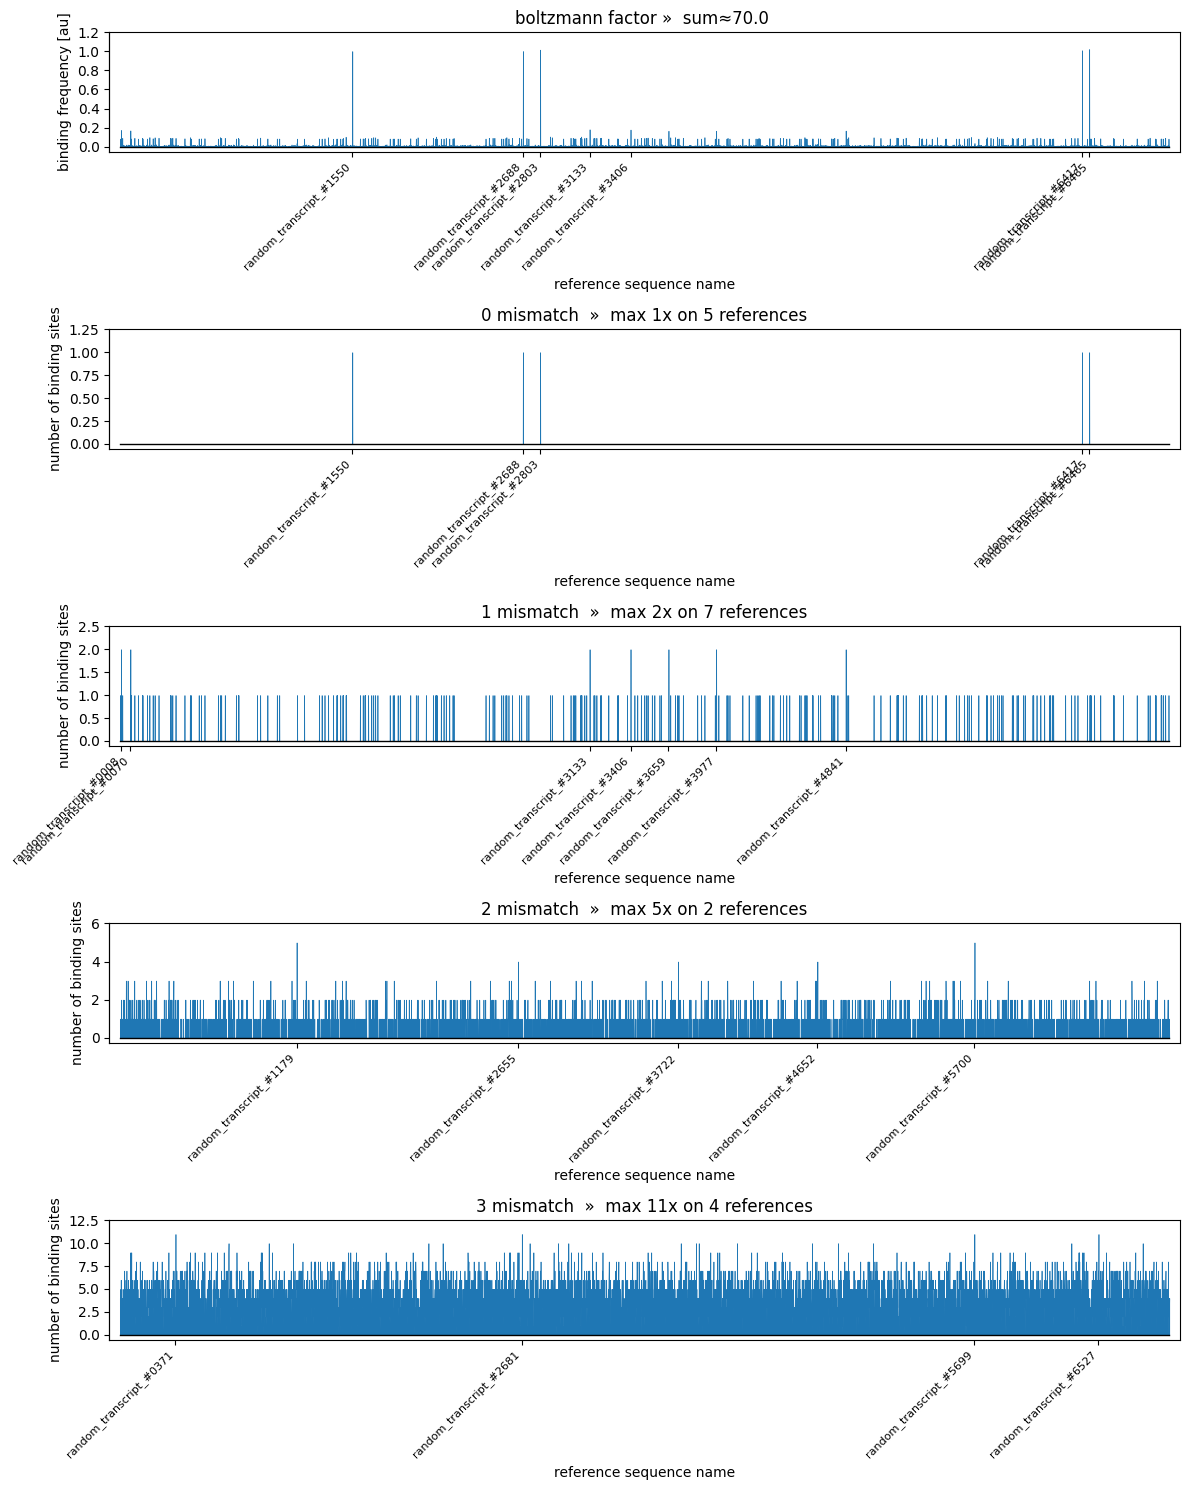

{'SEQ_NAME': 'random_target_246:256',
 'SEQUENCE': 'TCTAAATGAT',
 'WEIGHT': 1,
 'boltzmann factor max': np.float64(1.0235852974501003),
 'boltzmann factor sum': np.float64(69.97139489157368),
 'boltzmann factor VIR': ['random_transcript_#6465',
                          'random_transcript_#2803',
                          'random_transcript_#6417',
                          'random_transcript_#2688',
                          'random_transcript_#1550',
                          'random_transcript_#3133',
                          'random_transcript_#3406'],
 '0 mismatch max': np.float64(1.0),
 '0 mismatch sum': np.float64(5.0),
 '1 mismatch max': np.float64(2.0),
 '1 mismatch sum': np.float64(255.0),
 '2 mismatch max': np.float64(5.0),
 '2 mismatch sum': np.float64(3182.0),
 '3 mismatch max': np.float64(11.0),
 '3 mismatch sum': np.float64(25686.0)}


In [23]:
# generate random input sequences for this test
transcriptom = pd.DataFrame([{"SEQ_NAME": f"random_transcript_#{i:04d}", "SEQUENCE": random_seq(size = 1200), "WEIGHT": (np.random.poisson(5))**3 / 205} for i in range(7000)])      # The references to check against, i.e. the transcriptome in this example
target       = pd.Series(    {"SEQ_NAME": "random_target",               "SEQUENCE": random_seq(size = 800),   "WEIGHT": 1})                                        # The sequence from which we want ot find the best/unique binding site


# specify parameters
query_len = 10        # length of the binding sites (usually 8-12 for pumby)
plot = True                  # whether to show plots


# add the target itself to the list to check against
reference_list = transcriptom

# generate list of all possible binding sequences
query_list = pd.DataFrame([{"SEQ_NAME": target.SEQ_NAME + f"_{k:03d}:{k+query_len:03d}", "SEQUENCE":target.SEQUENCE[k:k+query_len],  "WEIGHT": target.WEIGHT} for k in range(len(target.SEQUENCE)-query_len)] )

# pick a random binding site candidate for this test
query = query_list.sample().iloc[0]  
pprint(scan_QxRL(query, reference_list, target, plot=True)['QxRL_summary'])

In [9]:
%timeit scan_QxRL(query_list.sample().iloc[0], reference_list)

559 ms ± 3.54 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
%timeit scan_QxRL(query_list.sample().iloc[0], reference_list)

561 ms ± 5.28 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
%timeit scan_QxRL(query_list.sample().iloc[0], reference_list)

559 ms ± 4.47 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


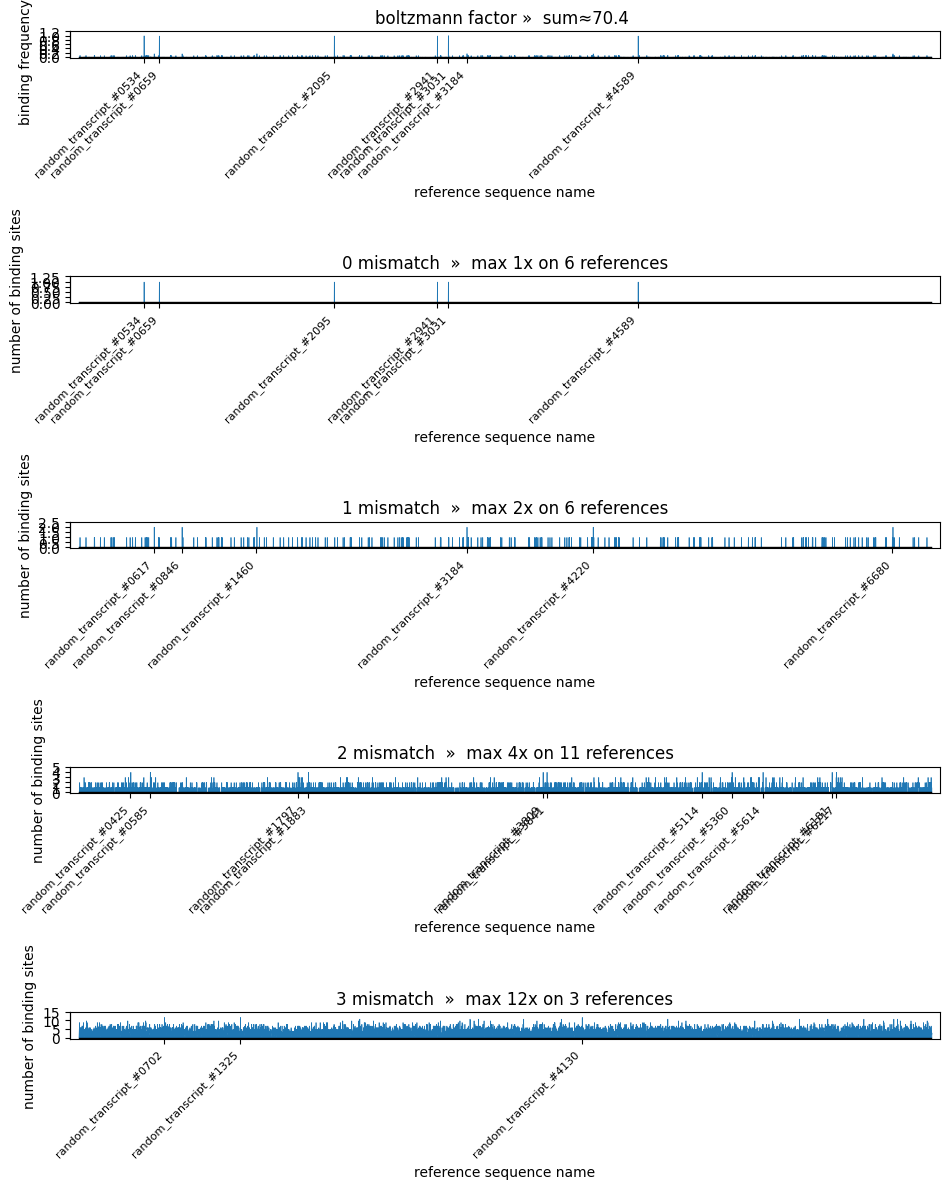

{'QxRL_results':                      SEQ_NAME  \
 0     random_transcript_#0000   
 1     random_transcript_#0001   
 2     random_transcript_#0002   
 3     random_transcript_#0003   
 4     random_transcript_#0004   
 ...                       ...   
 6995  random_transcript_#6995   
 6996  random_transcript_#6996   
 6997  random_transcript_#6997   
 6998  random_transcript_#6998   
 6999  random_transcript_#6999   
 
                                                SEQUENCE    WEIGHT  \
 0     AGATAAGTACTGTGAAAAGAAAGCCGTTGCGGACCGTACGAGTGCT...  3.556098   
 1     CCGGGCAATCCGCTCGCCGGTAAGGGGTCCTGAGCGATCCATATTG...  0.312195   
 2     GGAGGCCTCTAATCCCGGAGCTCTAATATCGCTATAAACACTCAGC...  3.556098   
 3     TGTTGGCTTAATCGGATTGATCGGACCCCTCTCAGCAGCAGCGTGG...  4.878049   
 4     TGTGAGTACGGCTGTGGGGACGCACGAGTCTAGTCGATCGTACGTG...  0.312195   
 ...                                                 ...       ...   
 6995  AGTCAGTGATCTGTCGGTGTTGCGTATGTGTATACAGCATGATAAT...  0.039024   
 6996  CTTACTC

In [12]:
scan_QxRL(query_list.sample().iloc[0], reference_list, plot = True)

In [13]:
scan_QxRL(query_list.sample().iloc[0], reference_list, plot = 'fig')

{'QxRL_results':                      SEQ_NAME  \
 0     random_transcript_#0000   
 1     random_transcript_#0001   
 2     random_transcript_#0002   
 3     random_transcript_#0003   
 4     random_transcript_#0004   
 ...                       ...   
 6995  random_transcript_#6995   
 6996  random_transcript_#6996   
 6997  random_transcript_#6997   
 6998  random_transcript_#6998   
 6999  random_transcript_#6999   
 
                                                SEQUENCE    WEIGHT  \
 0     AGATAAGTACTGTGAAAAGAAAGCCGTTGCGGACCGTACGAGTGCT...  3.556098   
 1     CCGGGCAATCCGCTCGCCGGTAAGGGGTCCTGAGCGATCCATATTG...  0.312195   
 2     GGAGGCCTCTAATCCCGGAGCTCTAATATCGCTATAAACACTCAGC...  3.556098   
 3     TGTTGGCTTAATCGGATTGATCGGACCCCTCTCAGCAGCAGCGTGG...  4.878049   
 4     TGTGAGTACGGCTGTGGGGACGCACGAGTCTAGTCGATCGTACGTG...  0.312195   
 ...                                                 ...       ...   
 6995  AGTCAGTGATCTGTCGGTGTTGCGTATGTGTATACAGCATGATAAT...  0.039024   
 6996  CTTACTC

In [14]:
%timeit scan_QxRL(query_list.sample().iloc[0], reference_list, skip_summary=True)

565 ms ± 6.29 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [15]:
%timeit scan_QxRL(query_list.sample().iloc[0], reference_list, target, relative_to_target = True)

569 ms ± 4.05 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [16]:
%timeit scan_QxRL(query_list.sample().iloc[0], reference_list, use_weights=True)

642 ms ± 188 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [17]:
%timeit scan_QxRL(query_list.sample().iloc[0], reference_list, target, relative_to_target = True, use_weights=True)

568 ms ± 3.23 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Batch evaluate all binding sites of target#
batch evaulate all queries generated as substrings from target

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import pandas as pd
from time import time
import warnings
from joblib import Parallel, delayed
from tqdm import tqdm
import pathlib
from IPython.display import display
from main_search import *


In [19]:
# generate random input sequences for this test
reference_list = pd.DataFrame([{"SEQ_NAME": f"random_transcript_#{i:04d}", "SEQUENCE": random_seq(size = 1200), "WEIGHT": (np.random.poisson(5))**3 / 205} for i in range(7000)])      # The references to check against, i.e. the transcriptome in this example
target            = pd.Series(    {"SEQ_NAME": "random_target",               "SEQUENCE": random_seq(size = 800),   "WEIGHT": 1})                                        # The sequence from which we want ot find the best/unique binding site

# specify parameters
query_len = 12                # length of the binding sites (usually 8-12 for pumby)
plot = False                  # whether to show plots

# generate list of all possible binding sequences
query_list = pd.DataFrame([{"POSITION": k, "SEQ_NAME": target.SEQ_NAME + f"_{k:03d}:{k+query_len:03d}", "SEQUENCE":target.SEQUENCE[k:k+query_len],  "WEIGHT": target.WEIGHT} for k in range(len(target.SEQUENCE)-query_len)] )

In [20]:
#-------------------------------#
#  Parallel processing: joblib  #  
#-------------------------------#          # using joblib instead of multiprocessing becasue of windows compatibility
from joblib import Parallel, delayed
from tqdm import tqdm

results = pd.DataFrame(list(tqdm(total=len(query_list), ncols = 100, 
        iterable=Parallel(return_as="generator", n_jobs=-1)(
            delayed(query_sc_summary)(query, reference_list, target) for row_ID, query in query_list.iterrows())
        )))

  0%|                                                                       | 0/788 [00:00<?, ?it/s]


NameError: name 'query_sc_summary' is not defined

In [ ]:
save_path = ".temp"
import pathlib
pathlib.Path(save_path).mkdir(parents=True, exist_ok=True) 
results.to_csv(                          pathlib.Path(save_path).joinpath(f"random_results.csv"),    index = False)
reference_list.to_csv(                pathlib.Path(save_path).joinpath(f"random_references.csv"), index = False)
pd.DataFrame([target]).to_csv(           pathlib.Path(save_path).joinpath(f"random_target.csv"),     index = False)

display(results)